# X-Route: resultados de las tres fases

En este notebook no volvemos a programar nada: importamos los módulos de `src/` y mostramos sus tablas y gráficas.
Todos los cálculos están en `src/`; aquí solo los reunimos en un mismo lugar para revisarlos con calma.

Antes de correrlo hay que haber ejecutado una vez `python src/descargar_grafo.py`, que es lo que crea `data/grafo_cdmx.graphml`.

In [1]:
import os
import sys

# El notebook vive en notebooks/, pero los módulos usan rutas relativas a la raíz del
# proyecto (data/, imagenes/, mapas/). Por eso primero nos cambiamos a la raíz y
# después agregamos src/ al path para poder importar los módulos.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, "src")

from IPython.display import Image, HTML, display
import html

from mapa import cargar_grafo, pares_origen_destino, nodo_mas_cercano, DEPOSITO
from fase1 import bfs, dfs, ucs, nodos_alcanzables
from fase2 import a_estrella, greedy, h1_euclidiana, h2_haversine, h3_personalizada

vecinos, coords = cargar_grafo()
pares = pares_origen_destino(coords)
deposito, _ = nodo_mas_cercano(coords, DEPOSITO[0], DEPOSITO[1])

print("Nodos:", len(vecinos))
print("Aristas (sin paralelas):", sum(len(lista) for lista in vecinos.values()))

Nodos: 5235
Aristas (sin paralelas): 11625


In [2]:
def imprimir_tabla(algoritmos):
    """Corre cada algoritmo en los 6 pares e imprime una fila por cada corrida."""
    print(f"{'Alg':6s} {'Destino':28s} {'Metros':>8s} {'Saltos':>7s} {'Expand.':>8s} {'Front.max':>9s} {'ms':>7s}")
    for nombre, origen, destino in pares:
        for nombre_alg, funcion in algoritmos:
            r = funcion(origen, destino)
            print(f"{nombre_alg:6s} {nombre:28s} {r['metros']:8.0f} {r['saltos']:7d} "
                  f"{r['expandidos']:8d} {r['frontera_max']:9d} {r['tiempo_ms']:7.2f}")
        print()

## Espacio de estados

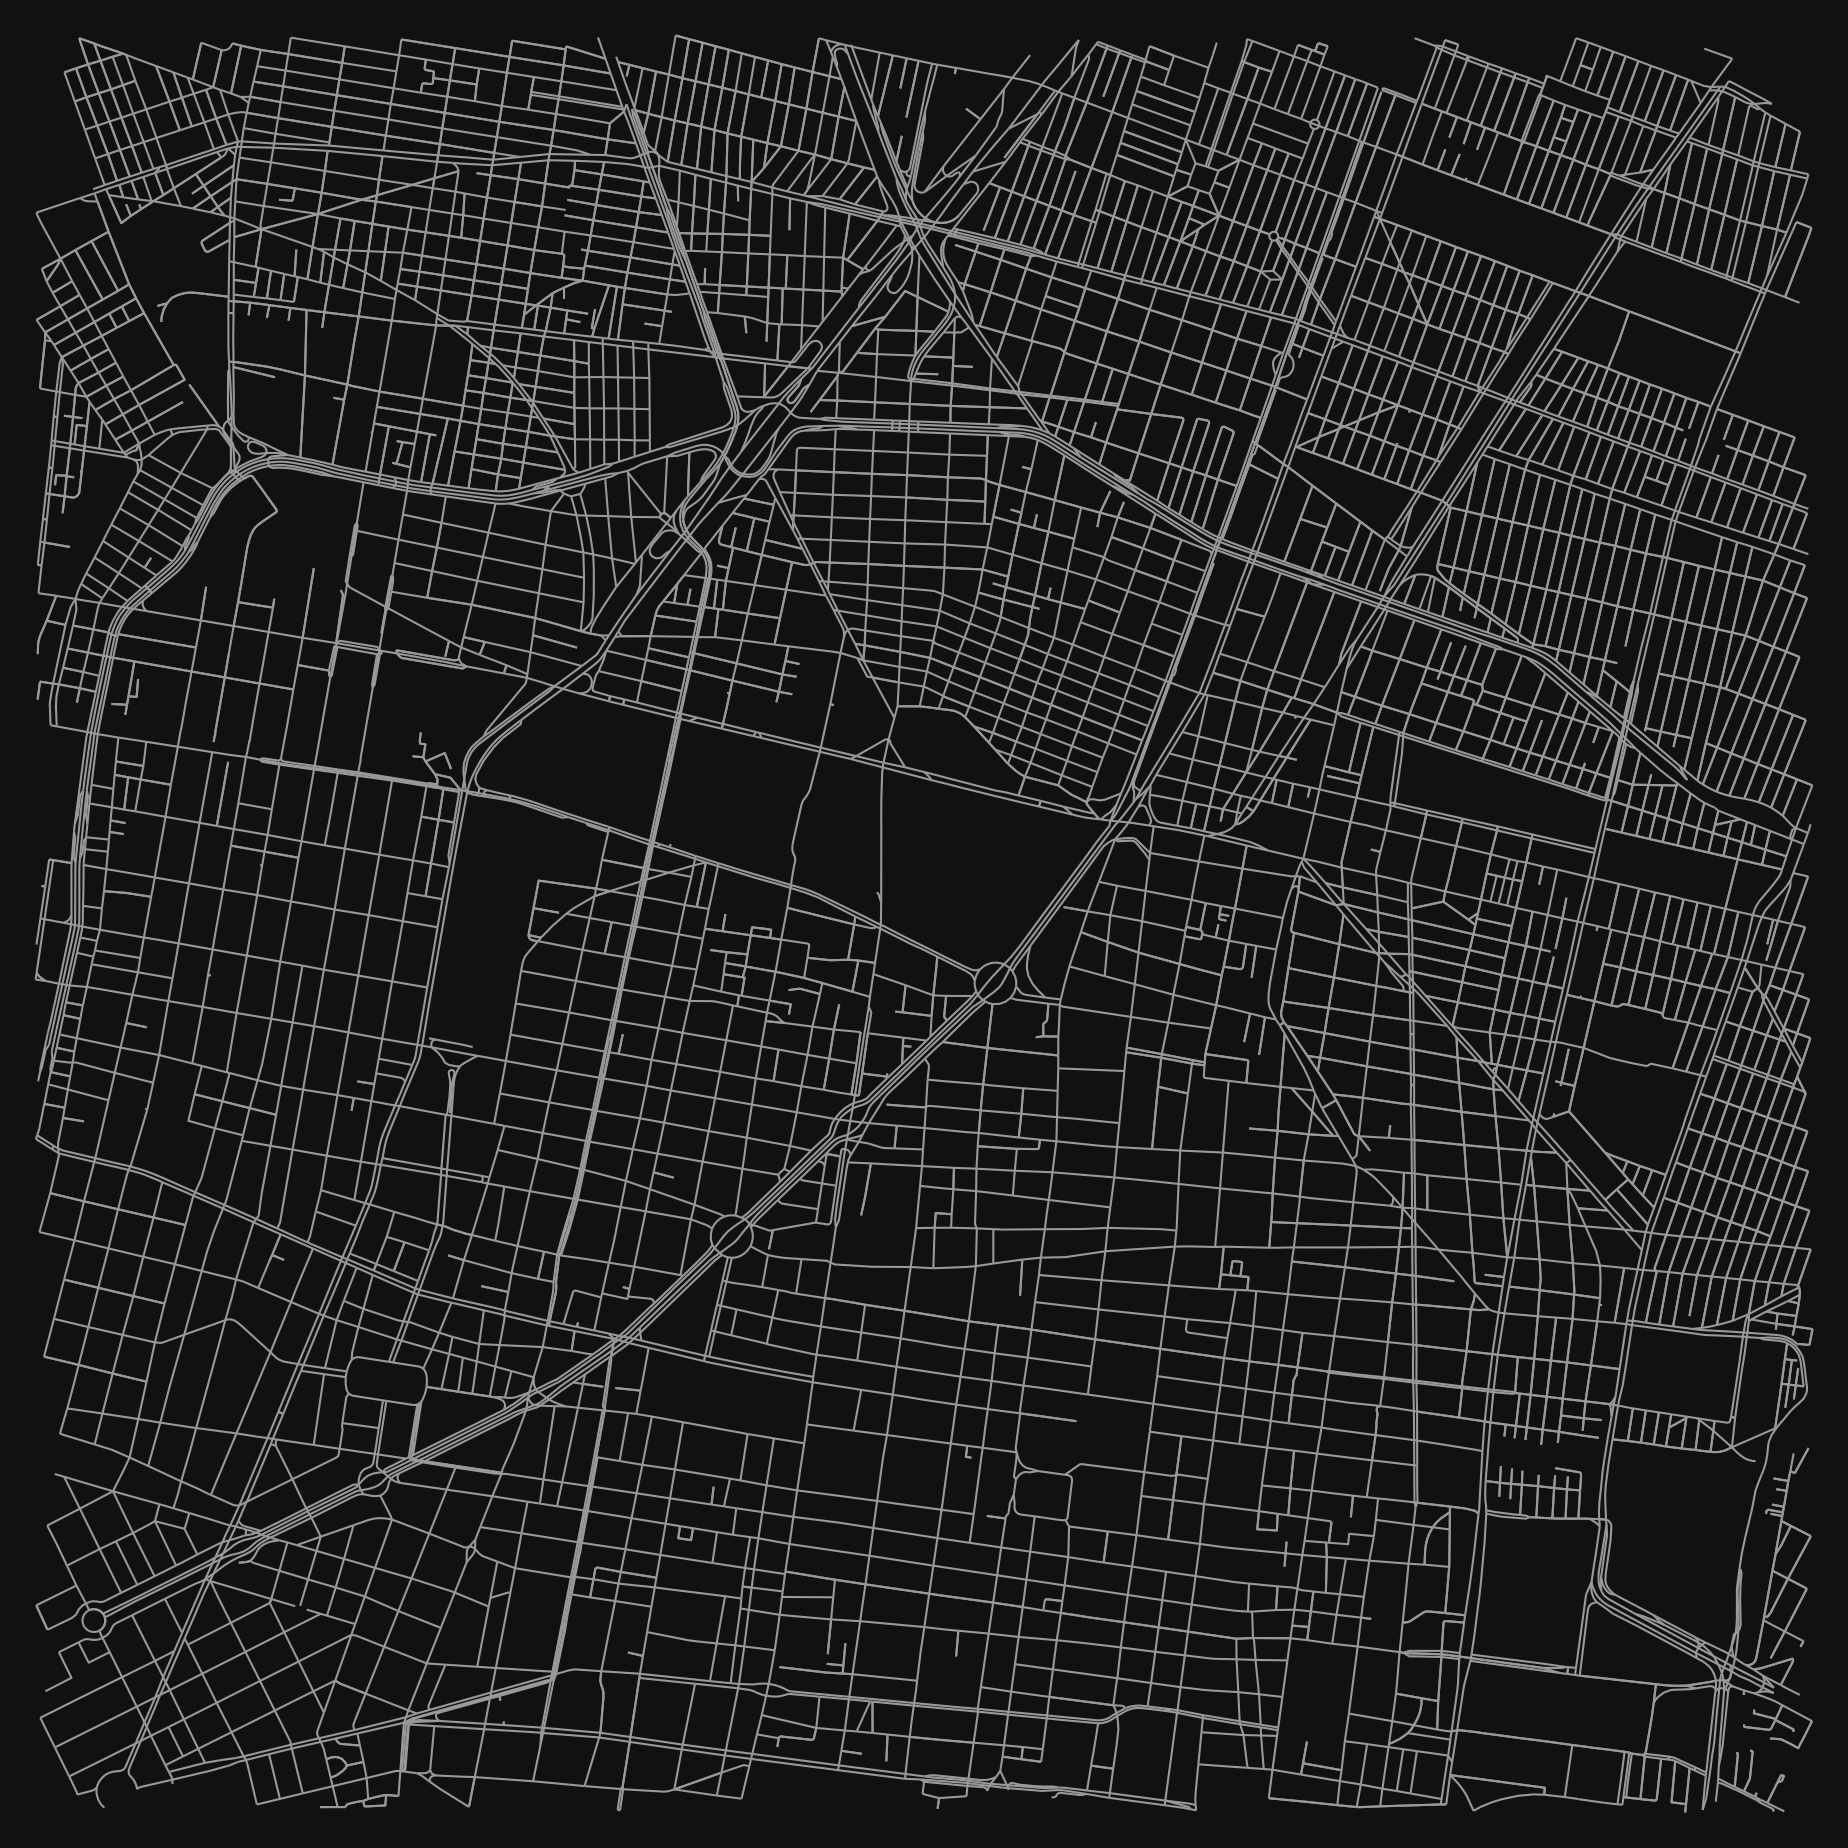

In [3]:
display(Image("data/grafo_cdmx.png", width=500))

## Fase 1: búsqueda a ciegas

BFS busca el camino con menos saltos, UCS el de menos metros, y DFS solo encuentra *algún* camino.

In [4]:
imprimir_tabla([
    ("BFS", lambda o, d: bfs(vecinos, o, d)),
    ("DFS", lambda o, d: dfs(vecinos, o, d)),
    ("UCS", lambda o, d: ucs(vecinos, o, d)),
])

Alg    Destino                        Metros  Saltos  Expand. Front.max      ms
BFS    Bellas Artes                     2897      20     1223       147    1.24
DFS    Bellas Artes                   135644    1334     3756      1009    3.72
UCS    Bellas Artes                     2655      25     1626       150    3.33

BFS    Garibaldi                        1995      15      587       128    0.37
DFS    Garibaldi                      133292    1316     3951      1043    3.98
UCS    Garibaldi                        1876      19      710       101    1.02

BFS    Monumento a la Revolución        3140      19     1106       146    0.67
DFS    Monumento a la Revolución       70637     670      936       480    0.66
UCS    Monumento a la Revolución        2669      26     1640       150    1.97

BFS    La Raza                          3765      30     2850       191    1.77
DFS    La Raza                         97226     954     1901       714    1.39
UCS    La Raza                       

### Verificación de accesibilidad desde el depósito

In [5]:
alcanzables = nodos_alcanzables(vecinos, deposito)
print("Alcanzables:", len(alcanzables), "de", len(vecinos), "nodos")
print("NO alcanzables:", len(vecinos) - len(alcanzables))
for nombre, _origen, destino in pares:
    print(f"  {nombre:28s} alcanzable: {destino in alcanzables}")

Alcanzables: 5169 de 5235 nodos
NO alcanzables: 66
  Bellas Artes                 alcanzable: True
  Garibaldi                    alcanzable: True
  Monumento a la Revolución    alcanzable: True
  La Raza                      alcanzable: True
  Tepito                       alcanzable: True
  Zócalo                       alcanzable: True


### Avance de la frontera (Depósito → La Raza)

Guardada: imagenes/snapshot_bfs.png


Guardada: imagenes/snapshot_dfs.png


Guardada: imagenes/snapshot_ucs.png


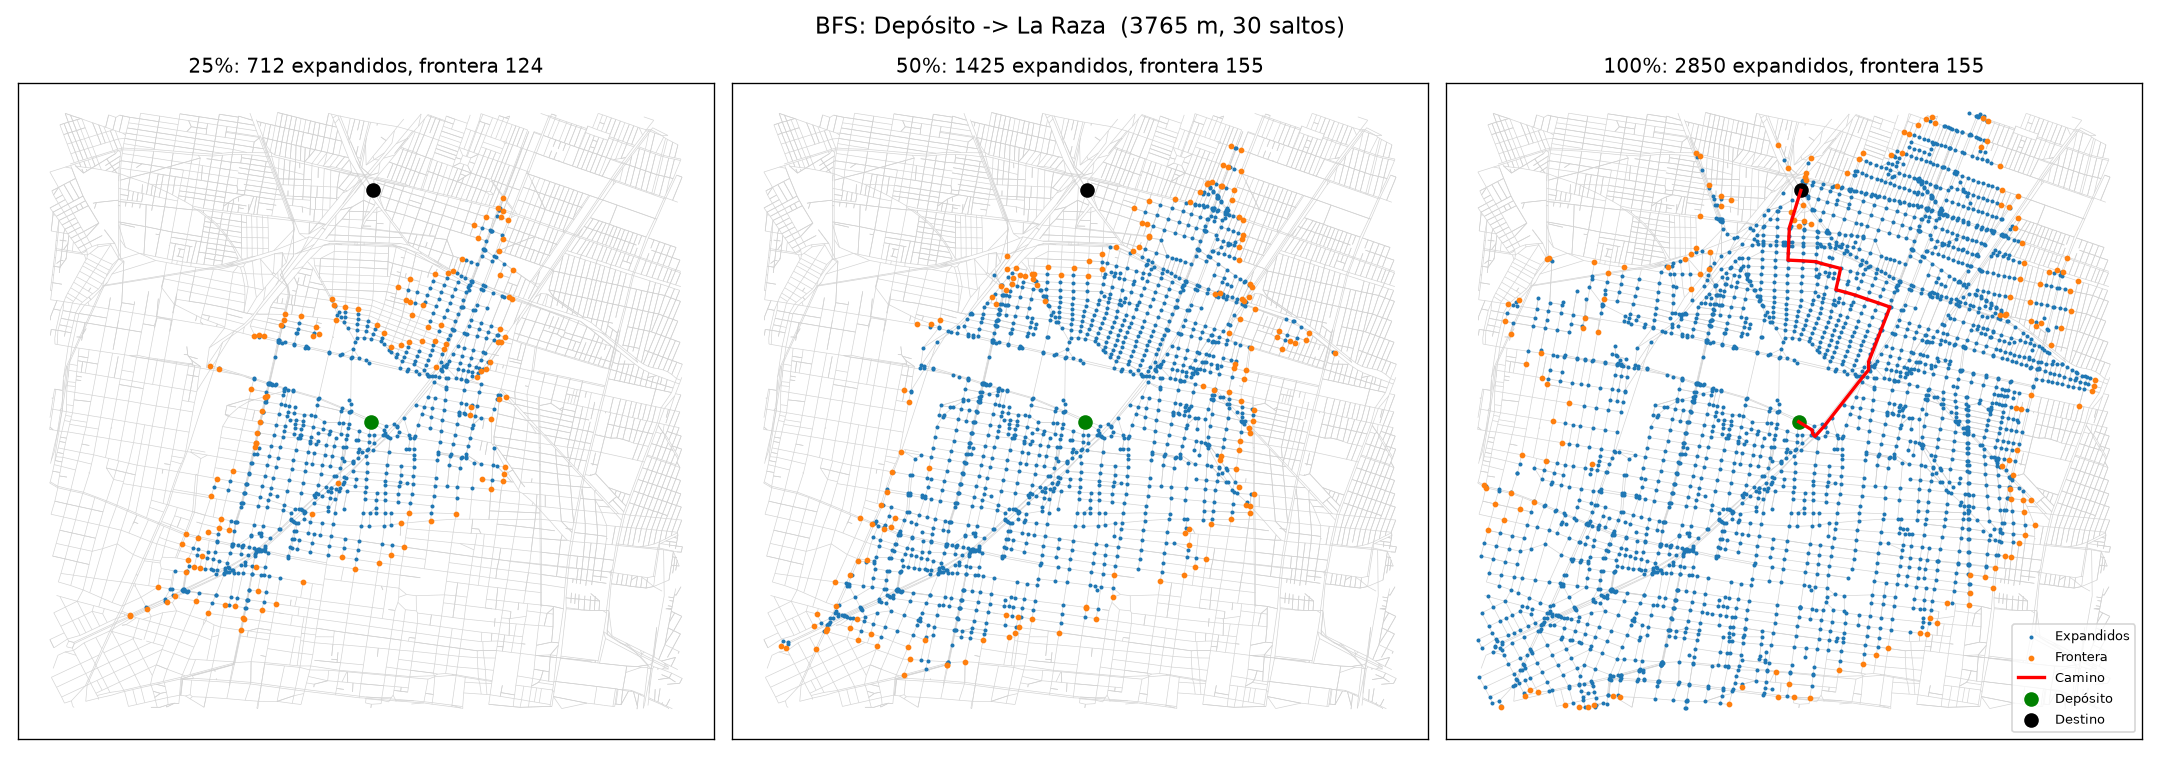

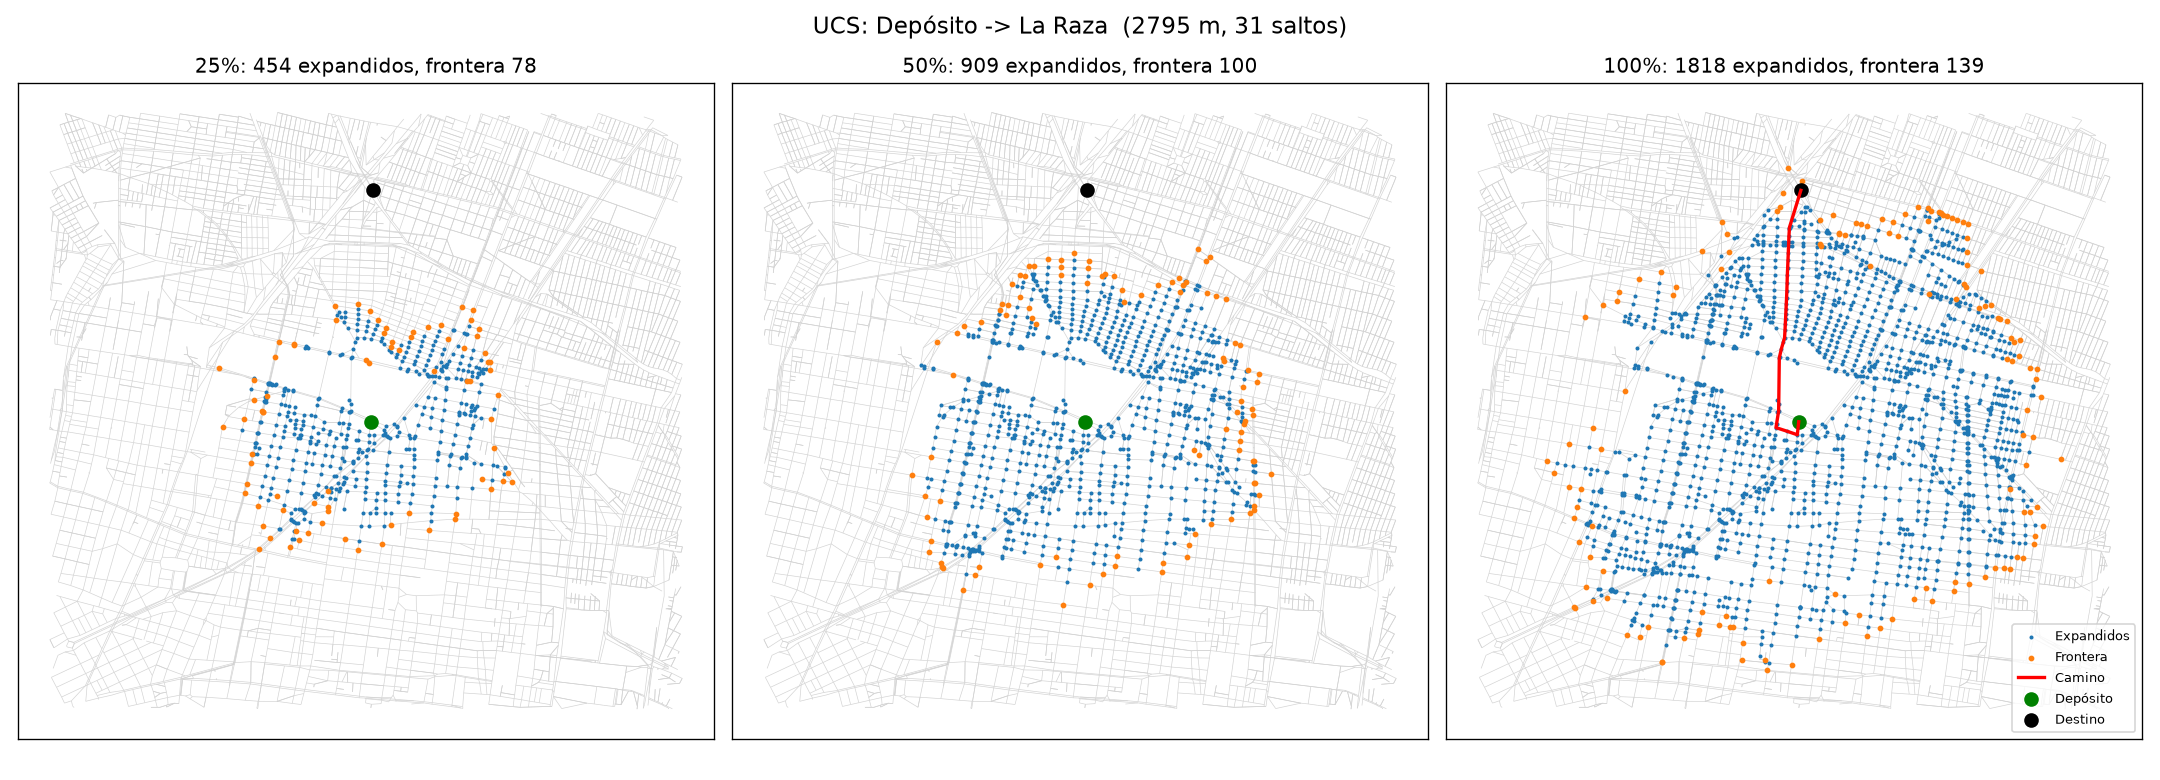

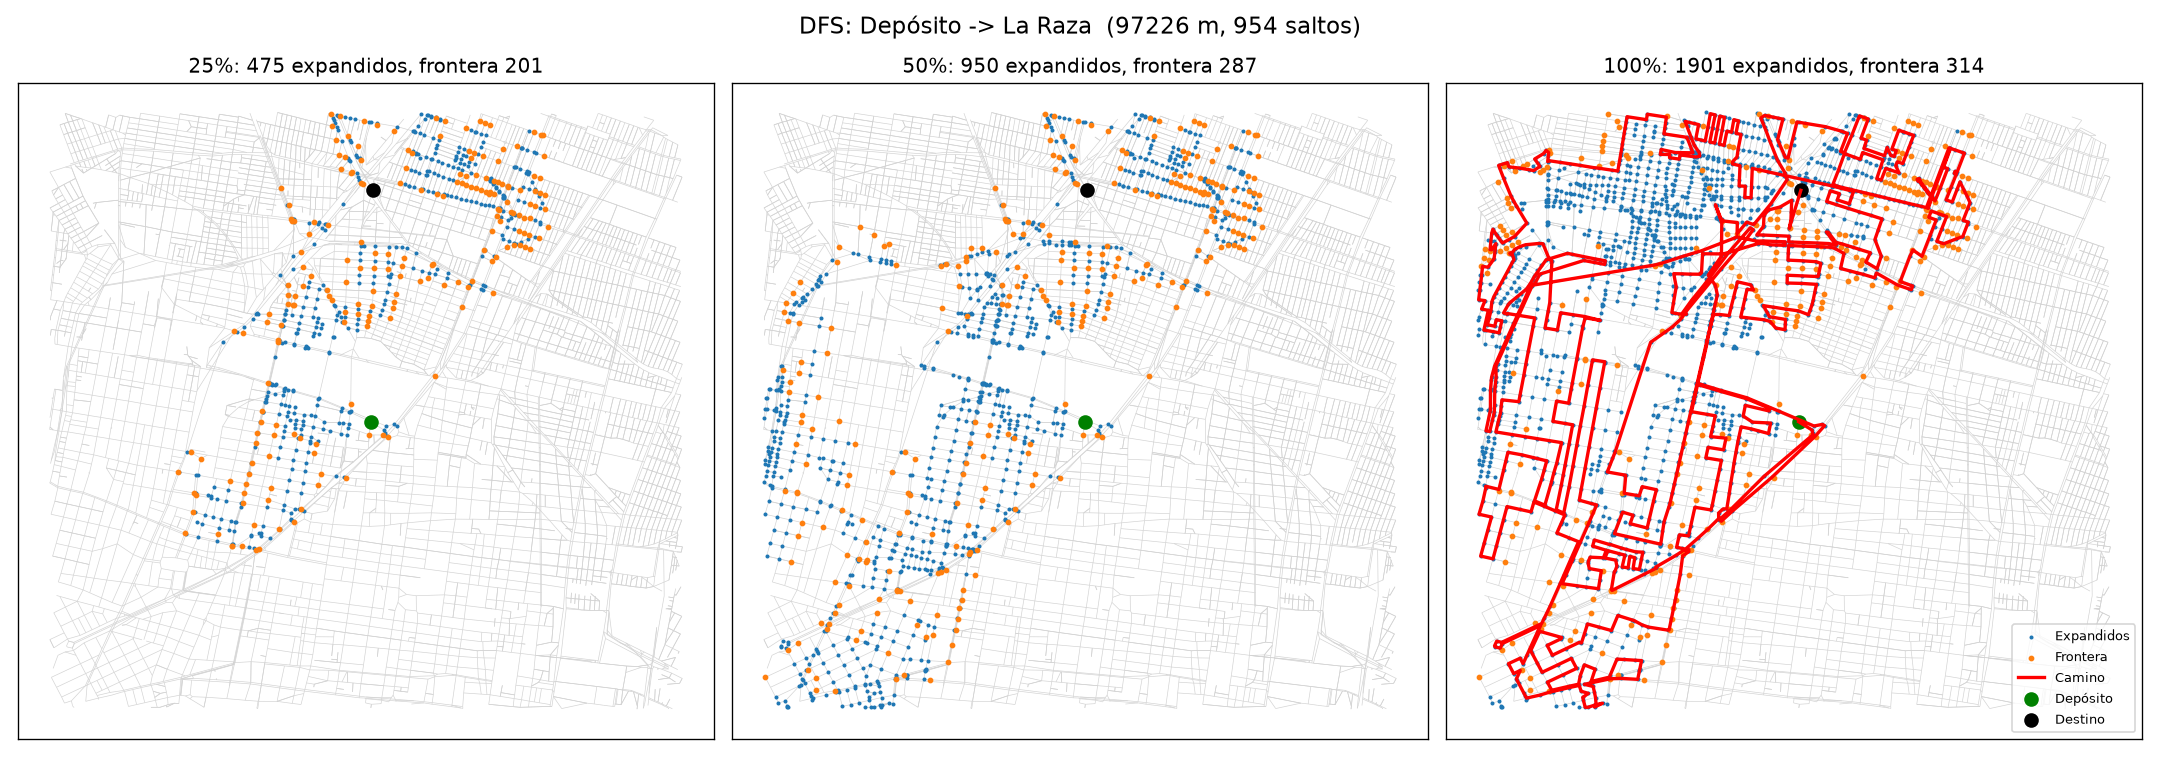

In [6]:
import snapshots_fase1
snapshots_fase1.main()

for alg in ("bfs", "ucs", "dfs"):
    display(Image(f"imagenes/snapshot_{alg}.png"))

## Fase 2: búsqueda informada

Comparamos A* con las tres heurísticas contra UCS, que nos sirve como referencia del óptimo, y contra Greedy.

In [7]:
imprimir_tabla([
    ("UCS", lambda o, d: ucs(vecinos, o, d)),
    ("A*-h1", lambda o, d: a_estrella(vecinos, coords, o, d, h1_euclidiana)),
    ("A*-h2", lambda o, d: a_estrella(vecinos, coords, o, d, h2_haversine)),
    ("A*-h3", lambda o, d: a_estrella(vecinos, coords, o, d, h3_personalizada)),
    ("Gr-h2", lambda o, d: greedy(vecinos, coords, o, d, h2_haversine)),
])

Alg    Destino                        Metros  Saltos  Expand. Front.max      ms
UCS    Bellas Artes                     2655      25     1626       150    3.74
A*-h1  Bellas Artes                     2655      25      275        50    1.24
A*-h2  Bellas Artes                     2655      25      275        50    1.59
A*-h3  Bellas Artes                     2655      25      269        52    2.98
Gr-h2  Bellas Artes                     3257      34       44        27    0.30

UCS    Garibaldi                        1876      19      710       101    2.27
A*-h1  Garibaldi                        1876      19      173        36    0.92
A*-h2  Garibaldi                        1876      19      173        36    1.51
A*-h3  Garibaldi                        1876      19      168        37    1.33
Gr-h2  Garibaldi                        2148      22       58        21    0.31

UCS    Monumento a la Revolución        2669      26     1640       150    5.15
A*-h1  Monumento a la Revolución      

### Validación empírica de admisibilidad

In [8]:
import admisibilidad
admisibilidad.main()

Heurística          Revisados  Sobreestima       %  Peor exceso (m)  h/h* prom.  Admisible
h1 Euclidiana           31050            0   0.00%              0.0       0.745  SÍ
h2 Haversine            31050            0   0.00%              0.0       0.745  SÍ
h3 Personalizada        31050           33   0.11%             50.0       0.754  NO
h2 x 1.2                31050         6405  20.63%            987.2       0.894  NO
h2 x 1.5                31050        25252  81.33%           2632.5       1.118  NO
h2 x 2.0                31050        30108  96.97%           5791.8       1.490  NO


### Mapa interactivo: A* (azul) contra Greedy (rojo)

Volvemos a generar los 6 mapas en `mapas/` y mostramos el de Monumento a la Revolución,
que es el caso donde Greedy más se equivoca.

In [9]:
import mapas_fase2
mapas_fase2.main()

with open("mapas/ruta_monumento_a_la_revolucion.html", encoding="utf-8") as f:
    contenido = f.read()
display(HTML(f'<div><iframe srcdoc="{html.escape(contenido)}" width="100%" height="500"></iframe></div>'))

Bellas Artes                 A*:   2655 m | Greedy:   3257 m (+602 m) -> mapas/ruta_bellas_artes.html
Garibaldi                    A*:   1876 m | Greedy:   2148 m (+272 m) -> mapas/ruta_garibaldi.html
Monumento a la Revolución    A*:   2669 m | Greedy:   3340 m (+671 m) -> mapas/ruta_monumento_a_la_revolucion.html
La Raza                      A*:   2795 m | Greedy:   3149 m (+355 m) -> mapas/ruta_la_raza.html
Tepito                       A*:   1813 m | Greedy:   1914 m (+101 m) -> mapas/ruta_tepito.html
Zócalo                       A*:   2634 m | Greedy:   3242 m (+608 m) -> mapas/ruta_zocalo.html


## Fase 3: búsqueda local (orden de 15 entregas)

Armamos la matriz de distancias de 16×16 con A* y corremos SA y AG con 5 semillas cada uno.

In [10]:
from fase3 import preparar_problema, distancia_ruta, simulated_annealing, algoritmo_genetico

puntos, matriz, _coords, _vecinos = preparar_problema()
ruta_inicial = list(range(1, len(puntos)))
print(f"Ruta en orden 1..{len(puntos) - 1}: {distancia_ruta(ruta_inicial, matriz):.0f} m")

print("\nSimulated Annealing (5 corridas):")
for semilla in range(5):
    r = simulated_annealing(matriz, semilla=semilla)
    print(f"  semilla {semilla}: {r['metros']:7.0f} m en {r['iteraciones']} iteraciones ({r['tiempo_ms']:.0f} ms)")

print("\nAlgoritmo Genético (5 corridas):")
for semilla in range(5):
    r = algoritmo_genetico(matriz, semilla=semilla)
    print(f"  semilla {semilla}: {r['metros']:7.0f} m en {r['evaluaciones']} evaluaciones ({r['tiempo_ms']:.0f} ms)")

Ruta en orden 1..15: 61835 m

Simulated Annealing (5 corridas):
  semilla 0:   31704 m en 9206 iteraciones (38 ms)
  semilla 1:   30552 m en 9206 iteraciones (45 ms)
  semilla 2:   30552 m en 9206 iteraciones (62 ms)
  semilla 3:   30845 m en 9206 iteraciones (59 ms)


  semilla 4:   31241 m en 9206 iteraciones (65 ms)

Algoritmo Genético (5 corridas):


  semilla 0:   31517 m en 20100 evaluaciones (283 ms)


  semilla 1:   30665 m en 20100 evaluaciones (357 ms)


  semilla 2:   31497 m en 20100 evaluaciones (255 ms)


  semilla 3:   34213 m en 20100 evaluaciones (378 ms)


  semilla 4:   32391 m en 20100 evaluaciones (447 ms)


### Recorrido del camión: sin optimizar contra SA

Guardada: imagenes/ruta_entregas_sa.png


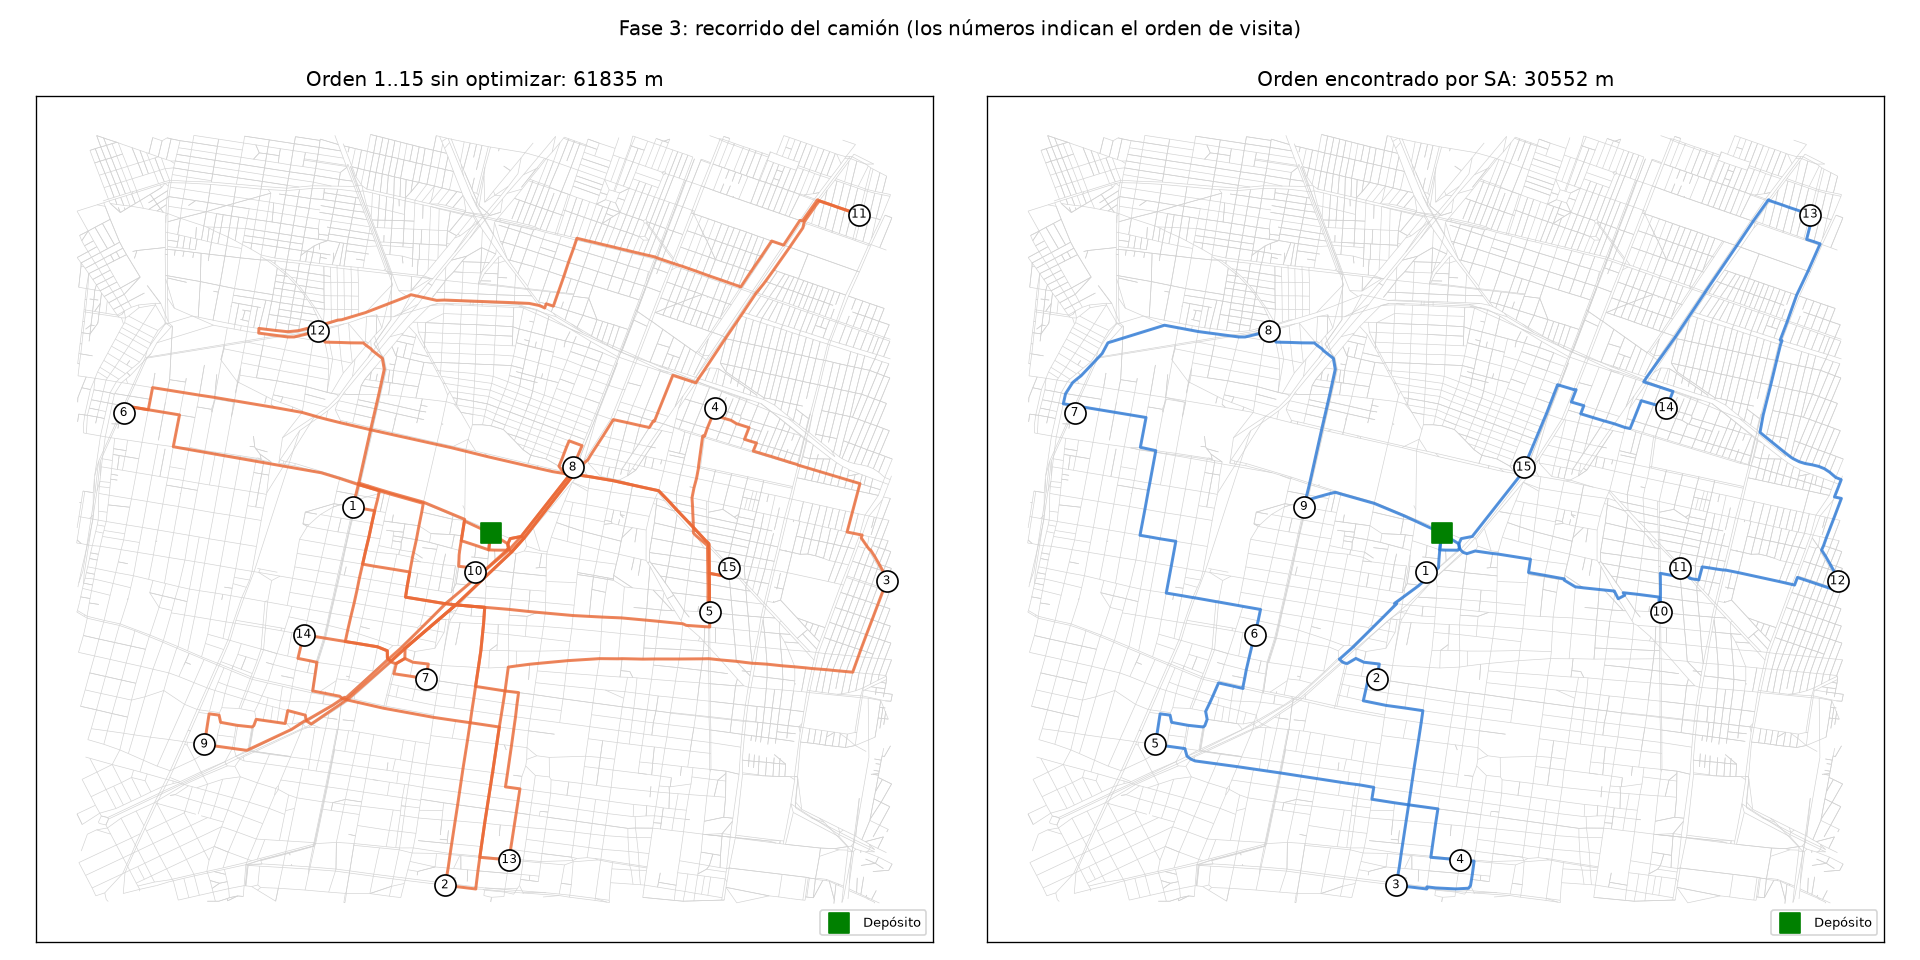

In [11]:
import ruta_entregas_fase3
ruta_entregas_fase3.main()
display(Image("imagenes/ruta_entregas_sa.png"))

### Convergencia de SA y AG, y experimento de la temperatura inicial T0

Guardada: imagenes/convergencia_sa_ag.png

Experimento de T0 (10 corridas por valor, 9206 iteraciones cada una):
    T0    Mejor  Promedio     Peor  Desv.est.  Rutas distintas


    10    30552     33014    36833       2280         10 de 10


   100    30214     31279    33330        938          8 de 10


  1000    30552     30975    31704        382          9 de 10


 10000    30214     30960    31815        474          9 de 10


Guardada: imagenes/experimento_t0.png


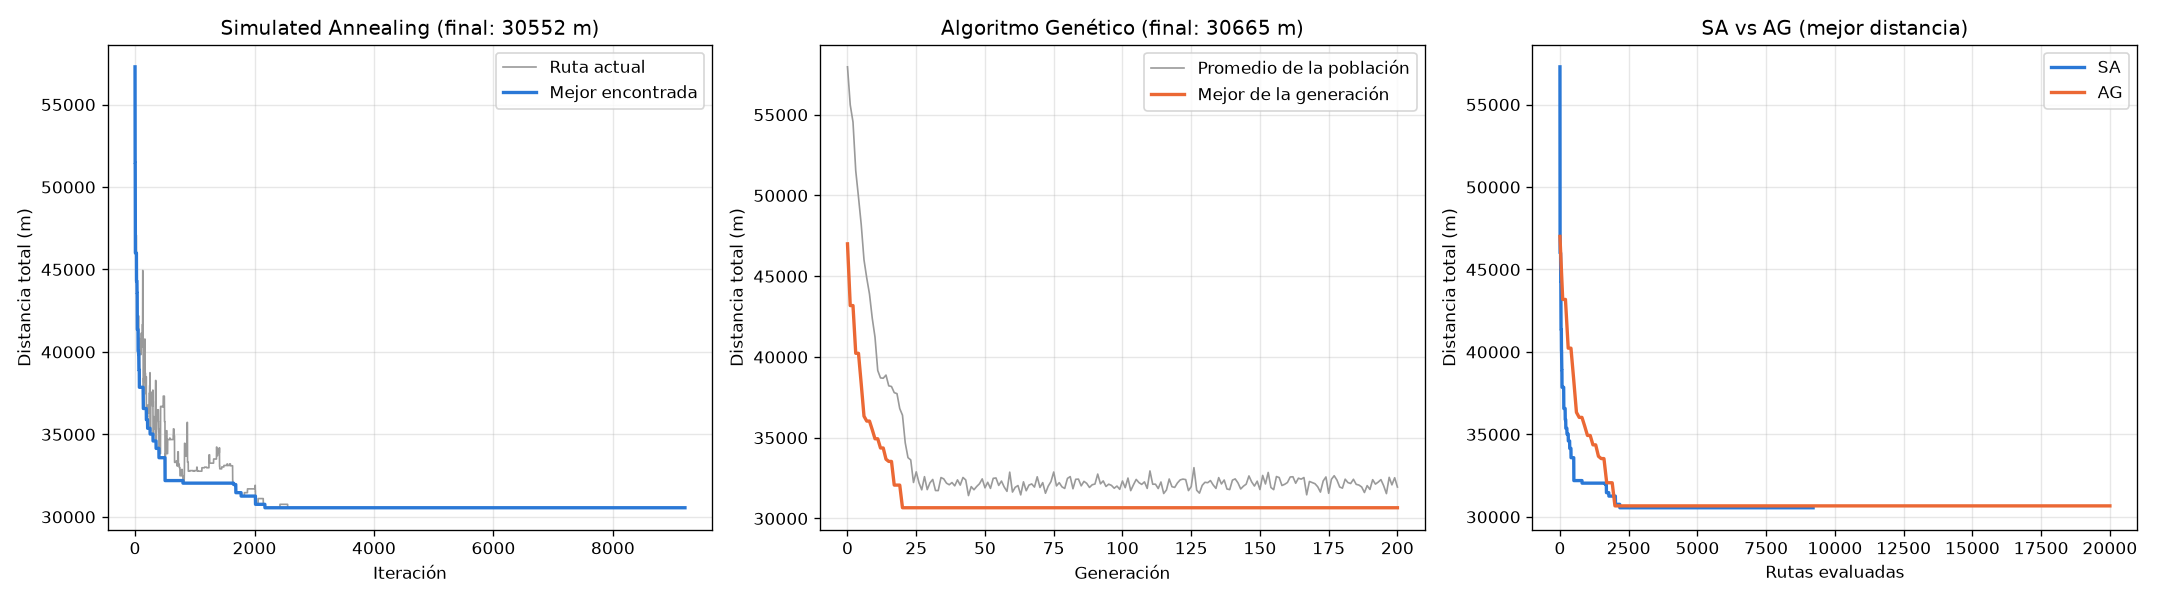

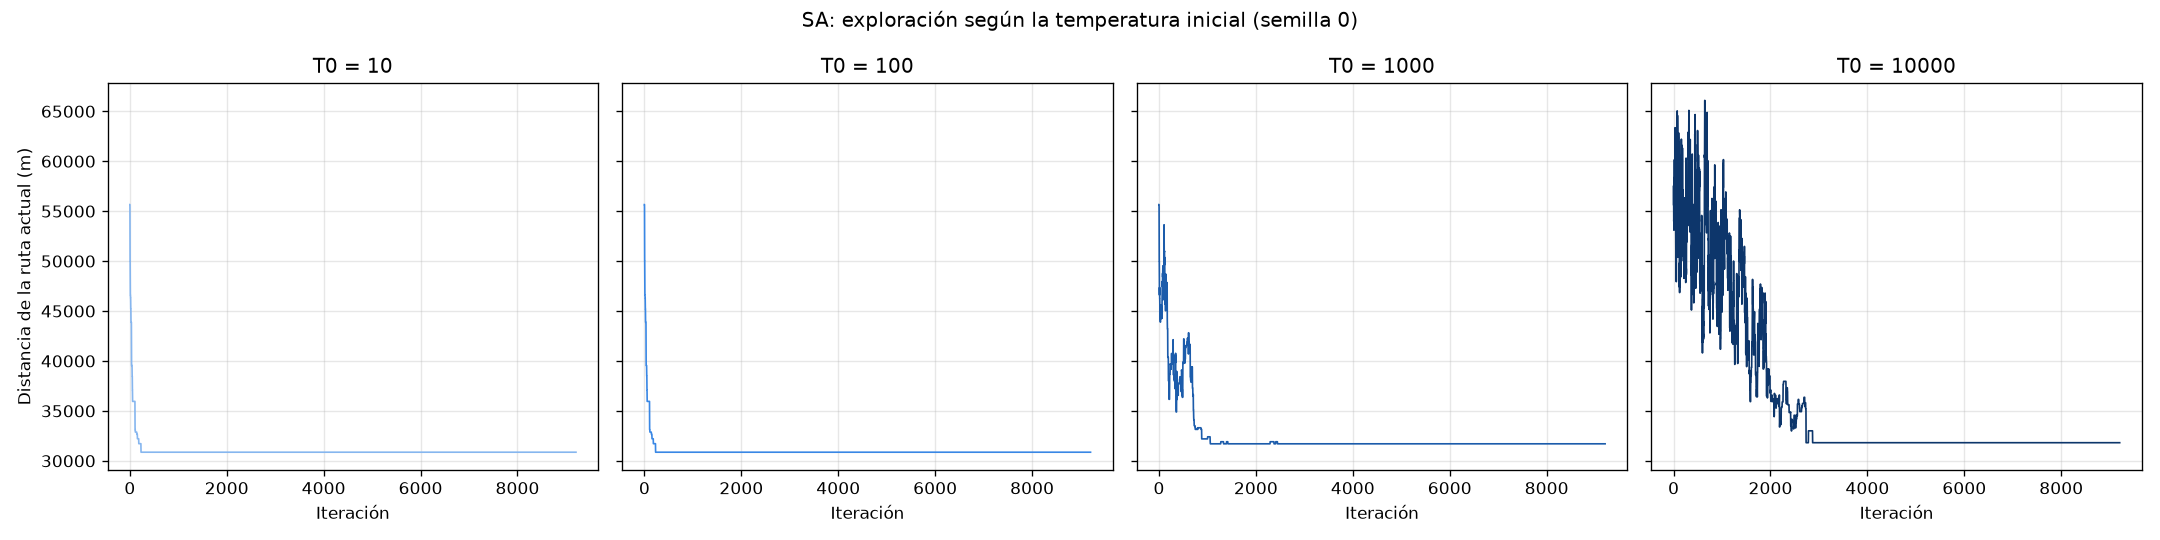

In [12]:
import graficas_fase3
graficas_fase3.grafica_convergencia(matriz)
graficas_fase3.experimento_t0(matriz)

display(Image("imagenes/convergencia_sa_ag.png"))
display(Image("imagenes/experimento_t0.png"))